# Supplier Analysis & Cost Optimization

In this project, I analyze purchasing data to understand supplier pricing, consumption patterns, and identify opportunities for cost optimization.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [43]:
np.random.seed(42)

suppliers = ['Guhring Inc', 'Guhring KG', 'Guhring Japan', 'Guhring Korea']
customers = ['Automotive Client', 'Industrial Client', 'Retail Client', 'OEM Client']

data = []

for i in range(200):
    supplier = np.random.choice(suppliers)
    customer = np.random.choice(customers)
    quantity = np.random.randint(1, 50)
    price = round(np.random.uniform(50, 150), 2)
    date = pd.date_range(start="2023-01-01", periods=200)[i]

    data.append([supplier, customer, quantity, price, date])

df = pd.DataFrame(data, columns=['supplier', 'customer', 'quantity', 'price', 'date'])

df.head()

,supplier,customer,quantity,price,date
0,Guhring Japan,OEM Client,29,68.34,2023-01-01
1,Guhring Korea,Automotive Client,21,65.60,2023-01-02
2,Guhring Japan,Retail Client,11,95.92,2023-01-03
3,Guhring Inc,OEM Client,40,120.81,2023-01-04
4,Guhring KG,Automotive Client,2,122.20,2023-01-05


In [44]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   supplier  200 non-null    object        
 1   customer  200 non-null    object        
 2   quantity  200 non-null    int64         
 3   price     200 non-null    float64       
 4   date      200 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 7.9+ KB


,quantity,price,date
count,200.000000,200.000000,200
mean,25.840000,104.786600,2023-04-10 12:00:00
min,1.000000,50.510000,2023-01-01 00:00:00
25%,12.750000,78.812500,2023-02-19 18:00:00
50%,27.000000,107.120000,2023-04-10 12:00:00
75%,38.250000,130.882500,2023-05-30 06:00:00
max,49.000000,149.770000,2023-07-19 00:00:00
std,14.722027,29.744727,NaN


In [45]:
# Check missing values
df.isnull().sum()

# Convert date column
df['date'] = pd.to_datetime(df['date'])

In [46]:
# Total cost calculation
df['total_cost'] = df['quantity'] * df['price']

## Price Analysis by Supplier

I wanted to understand which supplier tends to be more expensive on average.

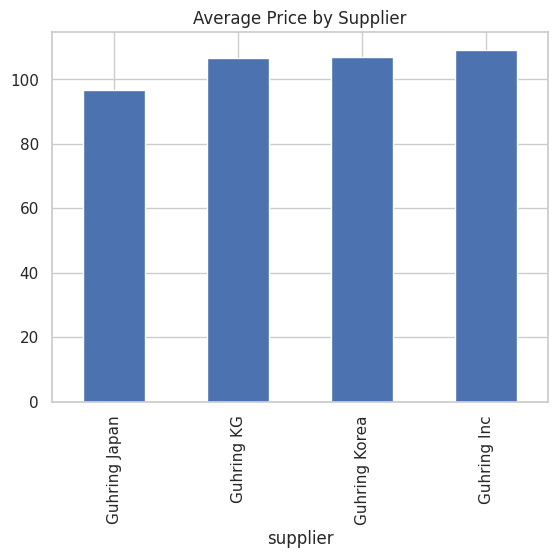

In [47]:
avg_price = df.groupby('supplier')['price'].mean().sort_values()

avg_price

avg_price.plot(kind='bar', title='Average Price by Supplier')
plt.show()

## Purchase Volume

Here I analyze how much we are buying from each supplier.

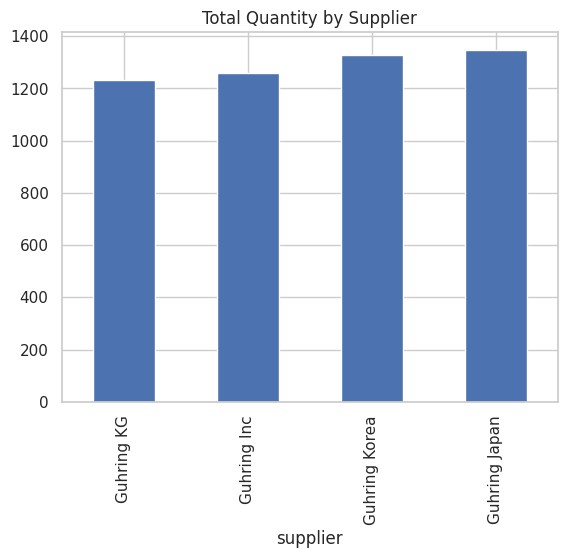

In [48]:
volume = df.groupby('supplier')['quantity'].sum().sort_values()

volume

volume.plot(kind='bar', title='Total Quantity by Supplier')
plt.show()

## Total Cost Analysis

This helps identify which supplier represents the highest cost.

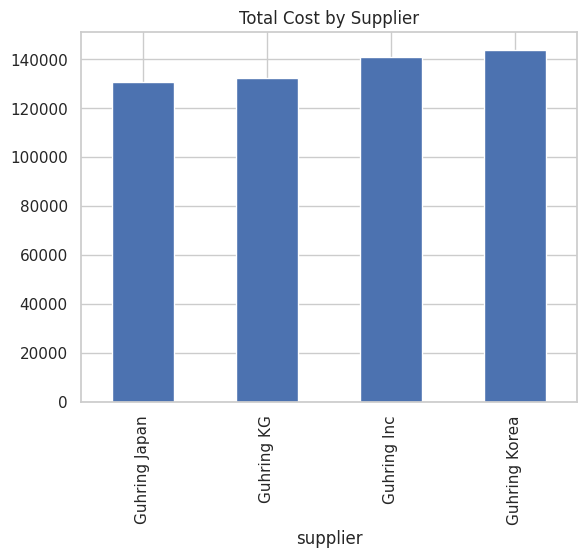

In [49]:
total_cost = df.groupby('supplier')['total_cost'].sum().sort_values()

total_cost
total_cost.plot(kind='bar', title='Total Cost by Supplier')
plt.show()

## Insights

Based on the analysis, I identified some interesting patterns.

In [50]:
print("Observations:")
print("The supplier with the lowest average price is:", avg_price.idxmin())
print("The supplier with the highest total cost is:", total_cost.idxmax())

Observations:
The supplier with the lowest average price is: Guhring Japan
The supplier with the highest total cost is: Guhring Korea


## Conclusion

Working on this analysis helped me understand how supplier selection and purchasing patterns impact overall costs.

Even simple analysis can reveal opportunities to improve decision-making and reduce expenses.